In [101]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [102]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [103]:
df = pd.read_csv("AIMLDataset.csv")

In [104]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [105]:

df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [106]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [107]:
df.shape
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [109]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [110]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [111]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [112]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [113]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

np.float64(0.13)

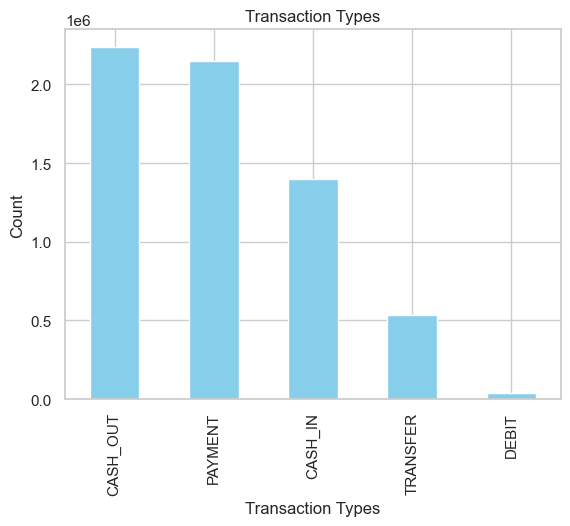

In [114]:
df["type"].value_counts().plot(kind = "bar", title = "Transaction Types", color = "skyblue")

plt.xlabel("Transaction Types")
plt.ylabel("Count")
plt.show()

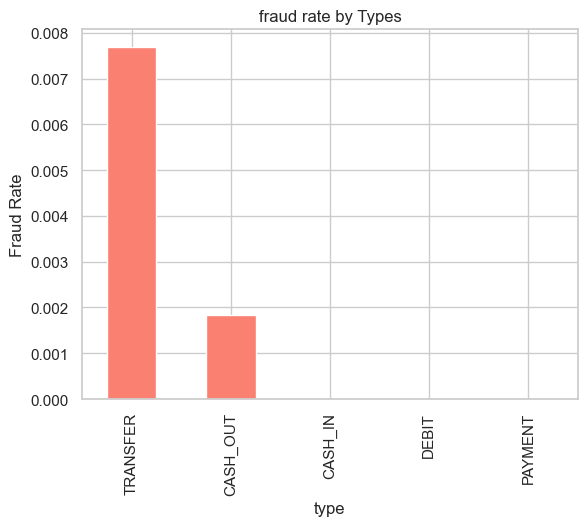

In [115]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind = "bar", title = "fraud rate by Types", color = "salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [116]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

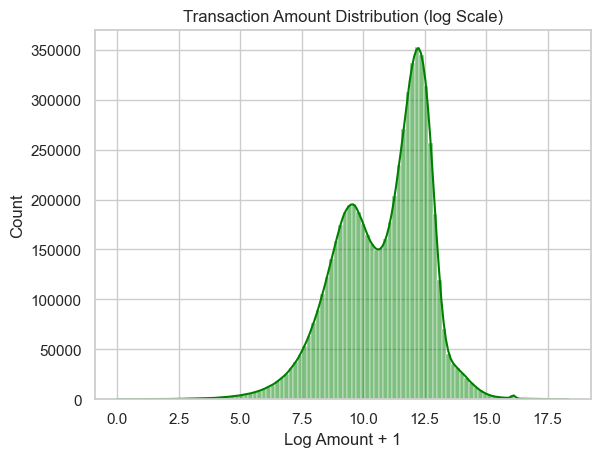

In [117]:
sns.histplot(
    np.log1p(df["amount"]),
    bins=100,
    kde=True,
    color="green"
)
plt.title("Transaction Amount Distribution (log Scale)")
plt.xlabel("Log Amount + 1")
plt.show()


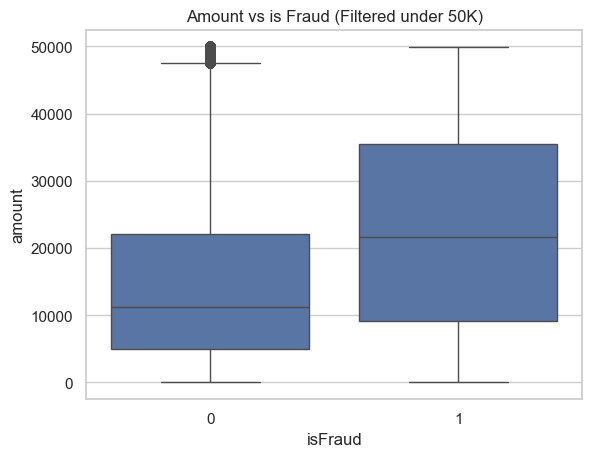

In [118]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs is Fraud (Filtered under 50K)")
plt.show()

In [119]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [120]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balancediffDest"] = df["oldbalanceDest"] - df["newbalanceDest"]

In [121]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [122]:
(df["balancediffDest"] < 0).sum()

np.int64(2806464)

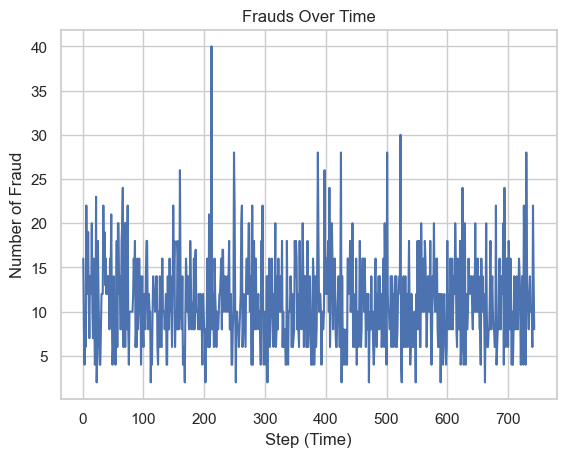

In [123]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values , label = "FraudsperStep")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Fraud")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [124]:
df.drop(columns="step",inplace = True)

In [125]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balancediffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [126]:
top_senders = df["nameOrig"].value_counts().head(10)

In [127]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [128]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balancediffDest'],
      dtype='object')

In [129]:
top_receivers = df["nameDest"].value_counts().head(10)

In [130]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [131]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balancediffDest'],
      dtype='object')

In [132]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [133]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [134]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [135]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balancediffDest'],
      dtype='object')

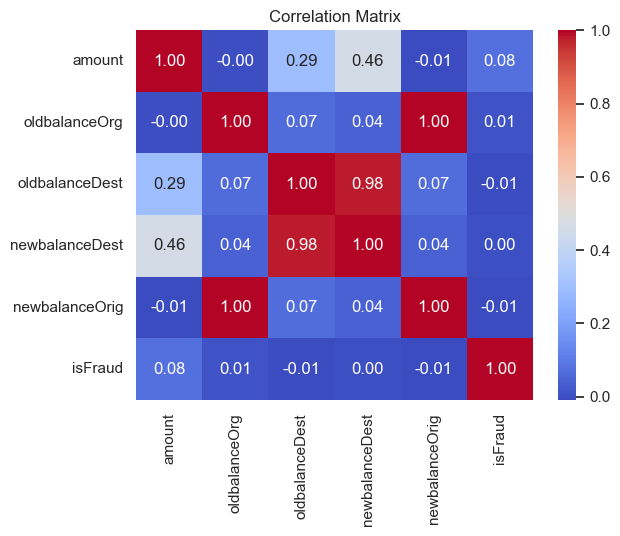

In [136]:
corr = df[[
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "newbalanceDest",
    "newbalanceOrig",
    "isFraud"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [137]:
zero_after_transfer = df[
    (df["oldbalanceDest"]>0)&
    (df["newbalanceOrig"]==0)
    &(df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [138]:
len(zero_after_transfer)

2170086

In [139]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balancediffDest
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0,181.00,21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.0,51513.44,0,0,15325.00,-46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.0,0.00,0,0,705.00,22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.0,2719172.89,0,0,10835.00,-2712905.89
42,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.0,2415.16,0,0,26845.41,286384.84


In [140]:
df_model = df.drop(columns = ["nameOrig","nameDest","isFlaggedFraud"], axis = 1 )

In [141]:
df_model.head(10)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balancediffDest
0,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,0,9839.64,0.00
1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,0,1864.28,0.00
2,TRANSFER,181.00,181.00,0.00,0.0,0.00,1,181.00,0.00
3,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,1,181.00,21182.00
4,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,0,11668.14,0.00
5,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,0,7817.71,0.00
6,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,0,7107.77,0.00
7,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,0,7861.64,0.00
8,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,0,2671.00,0.00
9,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,0,5337.77,1549.21


In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [143]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balancediffDest'],
      dtype='object')

In [144]:
categorical = ["type"]
numerical = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [145]:
X = df_model.drop("isFraud",axis=1)
y = df_model["isFraud"]

# Train Test Split

X_train , X_test , y_train, y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42 , stratify = y
)

In [146]:
# columnTransformerpreprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat",OneHotEncoder(drop="first"),categorical)
])

lr_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression (max_iter = 1000 , class_weight = "balanced"))
])

# Train pipeline

lr_pipeline.fit(X_train , y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [147]:
# Predict Model

y_pred = lr_pipeline.predict(X_test)

# Evaluate Model 

from sklearn.metrics import precision_score , recall_score

print("classification report :",classification_report)
recall = recall_score(y_test, y_pred) * 100

print("Recall Score:", recall, "%")

precision_score = precision_score(y_test , y_pred) * 100

print("precision_score: ", precision_score , "%")

classification report : <function classification_report at 0x0000021F9B3EC9A0>
Recall Score: 94.33962264150944 %
precision_score:  2.2126736235028766 %


In [148]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [149]:
# XG BOOST 

from xgboost import XGBClassifier

ratio = len(y_train[y_train == 0]) / len(y_train[y_train==1])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=ratio,  # ← Imbalance fix
        random_state=42
    ))
])

xgb_pipeline.fit(X_train , y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [150]:
from sklearn.metrics import precision_score, recall_score

y_pred_xgb = xgb_pipeline.predict(X_test)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Precision Score:", precision_score(y_test, y_pred_xgb))
print("Recall Score:", recall_score(y_test, y_pred_xgb))

[[1258614   12267]
 [     19    1624]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.12      0.99      0.21      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.99      0.60   1272524
weighted avg       1.00      0.99      0.99   1272524

Precision Score: 0.11691022964509394
Recall Score: 0.9884357881923311


In [151]:
import joblib

joblib.dump(rf_pipeline, "fraud_detection_pipeline.pkl")
print("Random Forest Model Saved")

Random Forest Model Saved
